In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
import nibabel as nb
from package jsaomn.org import theory
from passlib

In [2]:
df = pd.read_csv("skill_demand_timeseries.csv")
df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Skill,Demand_Count
0,2022-01-01,Python,1220
1,2022-02-01,Python,1218
2,2022-03-01,Python,1272
3,2022-04-01,Python,1330
4,2022-05-01,Python,1282


In [3]:
def forecast_skill_growth(df, skill_name, future_steps=6):

    skill_df = df[df["Skill"] == skill_name].copy()
    skill_df = skill_df.sort_values("Date")

    # Create time index
    skill_df["Time_Index"] = np.arange(len(skill_df))

    X = skill_df[["Time_Index"]]
    y = skill_df["Demand_Count"]

    # Train model
    model = LinearRegression()
    model.fit(X, y)

    # Predict future
    last_index = skill_df["Time_Index"].iloc[-1]
    future_index = np.arange(last_index + 1, last_index + 1 + future_steps)
    future_X = future_index.reshape(-1, 1)

    future_predictions = model.predict(future_X)

    current_demand = y.iloc[-1]
    future_demand = future_predictions[-1]

    growth_percent = ((future_demand - current_demand) / current_demand) * 100

    return round(growth_percent, 2), future_predictions, skill_df

In [4]:
growth, future_pred, skill_df = forecast_skill_growth(df, "Cloud")

print("Cloud projected 6-month growth:", growth, "%")

Cloud projected 6-month growth: 3.79 %


/opt/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [5]:
skills = df["Skill"].unique()

growth_results = []

for skill in skills:
    growth, _, _ = forecast_skill_growth(df, skill)
    growth_results.append((skill, growth))

growth_df = pd.DataFrame(growth_results, columns=["Skill", "Projected_Growth_%"])
growth_df = growth_df.sort_values(by="Projected_Growth_%", ascending=False)

growth_df

/opt/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression wa

,Skill,Projected_Growth_%
6,GenAI,9.31
5,DevOps,5.82
2,Machine Learning,4.98
0,Python,4.36
1,Cloud,3.79
3,Data Science,-0.09
4,Web Development,-16.96


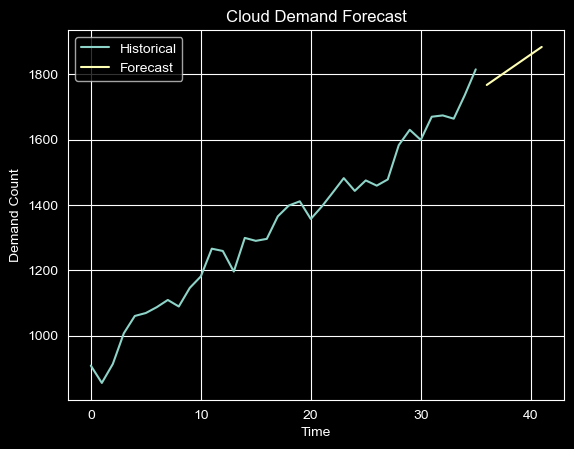

In [6]:
plt.figure()

plt.plot(skill_df["Time_Index"], skill_df["Demand_Count"], label="Historical")
plt.plot(
    np.arange(skill_df["Time_Index"].iloc[-1] + 1,
              skill_df["Time_Index"].iloc[-1] + 7),
    future_pred,
    label="Forecast"
)

plt.title("Cloud Demand Forecast")
plt.xlabel("Time")
plt.ylabel("Demand Count")

plt.legend()
plt.show()

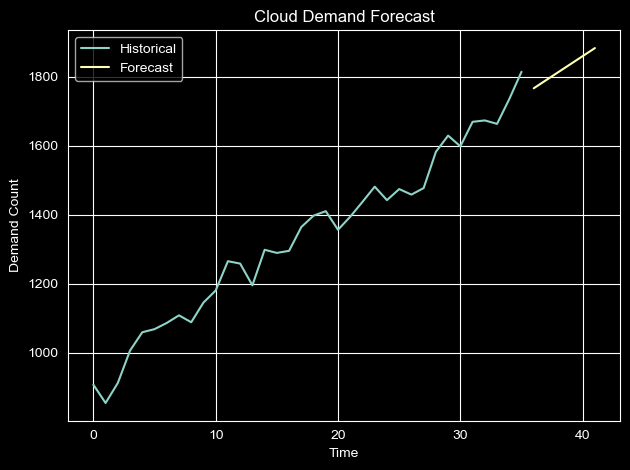

In [9]:
plt.figure()

plt.plot(skill_df["Time_Index"], skill_df["Demand_Count"], label="Historical")
plt.plot(
    np.arange(skill_df["Time_Index"].iloc[-1] + 1,
              skill_df["Time_Index"].iloc[-1] + 7),
    future_pred,
    label="Forecast"
)

plt.title("Cloud Demand Forecast")
plt.xlabel("Time")
plt.ylabel("Demand Count")
plt.legend()
plt.tight_layout()

plt.savefig("cloud_forecast.png")  # <-- saves image
plt.show()